In [409]:
import numpy as np  
import pandas as pd

baseline = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/exp1110/baseline_o82.csv')
# joint = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/joint_L.csv')
teachnet = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/exp1110/exp1103_teachnet/'+ 'o8_pose2' + '.csv')
NN = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/exp1110/NN_o82.csv')

In [410]:
# finger_NN = NN.columns[3:6]
# init=[-0.1278197169303894, 1.9431181728839875, 12.401289129257203]
# extend=[13.355320978164674, 10.181143426895142, -1.7475533306598663]

# init = np.array([-0.1278197169303894, 1.9431181728839875, 12.401289129257203])
# extend = np.array([13.355320978164674, 10.181143426895142, -1.7475533306598663])

# diff = extend - init  # shape (3,)
# # diff = 15 * np.ones(3)

# # make sure NN[finger_NN] is numpy array with shape (N,3)
# modify = 0.35 * (NN[finger_NN] - init[None, :]) / diff[None, :]


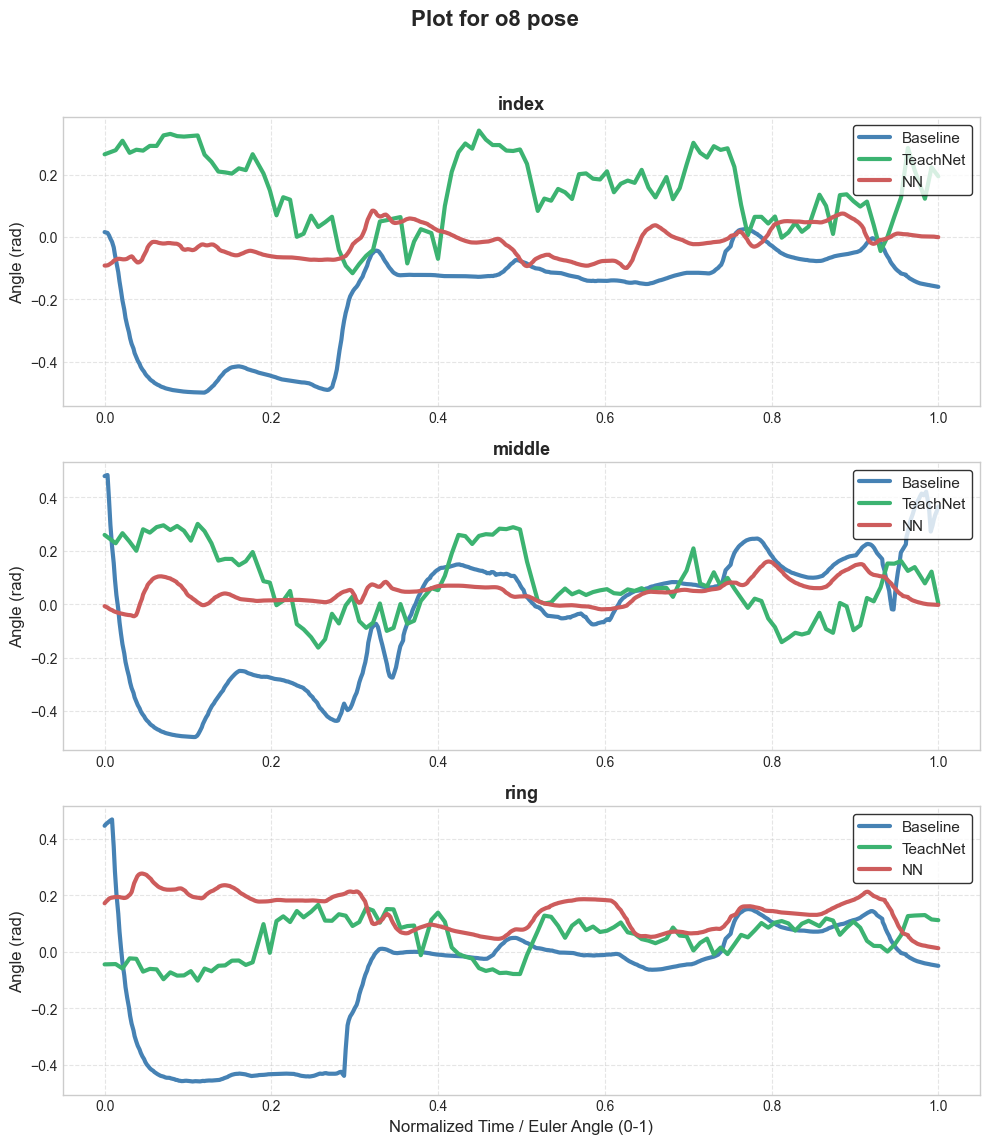

In [412]:
import pandas as pd
import matplotlib.pyplot as plt

# Conversion constants
radTodeg = 180 / 3.14159265358979323846
degTorad = 1 / radTodeg

# Create subplots (3 rows × 1 column)
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
name = ["index", "middle", "ring"]

# Column references
euler_angle_NN = NN.columns[0]
finger_NN = NN.columns[3:6]

euler_angle_baseline = baseline.columns[0]
finger_baseline = baseline.columns[3:6]

finger_teachnet = [4, 13, 17]
time_teachnet = teachnet.columns[0]

# === Color setup (slightly darker tones) ===
colors = {
    "baseline": "#4682B4",   # Steel blue
    "teachnet": "#3CB371",   # Medium sea green
    "nn": "#CD5C5C"          # Indian red
}

# === Plot loop ===
for i, (row_NN, row_baseline, row_teachnet) in enumerate(zip(finger_NN, finger_baseline, finger_teachnet)):
    # Convert to radians if needed
    nn_norm = NN[row_NN] * degTorad
    baseline_norm = baseline[row_baseline]
    teachnet_norm = -teachnet[teachnet.columns[row_teachnet]]

    # Compute variance
    var_nn = nn_norm.var()
    var_baseline = baseline_norm.var()

    # Normalize x values to 0–1
    x_nn = NN[euler_angle_NN]
    x_teachnet = teachnet[time_teachnet]
    x_baseline = baseline[euler_angle_baseline]

    x_nn_norm = (x_nn - x_nn.min()) / (x_nn.max() - x_nn.min())
    x_teachnet_norm = (x_teachnet - x_teachnet.min()) / (x_teachnet.max() - x_teachnet.min())
    x_baseline_norm = (x_baseline - x_baseline.min()) / (x_baseline.max() - x_baseline.min())

    # === Plot lines (solid, bold) ===
    axes[i].plot(x_baseline_norm, baseline_norm, label="Baseline",
                 color=colors["baseline"], linestyle='-', linewidth=3.0)
    axes[i].plot(x_teachnet_norm, teachnet_norm, label="TeachNet",
                 color=colors["teachnet"], linestyle='-', linewidth=3.0)
    axes[i].plot(x_nn_norm, nn_norm, label="NN",
                 color=colors["nn"], linestyle='-', linewidth=3.0)

    # Variance annotation box
    # axes[i].text(0.05, 0.95,
    #              f"NN var={var_nn:.4e}\nBaseline var={var_baseline:.4e}",
    #              transform=axes[i].transAxes,
    #              verticalalignment='top',
    #              fontsize=10,
    #              bbox=dict(facecolor='white', alpha=0.6))

    # Axis formatting
    axes[i].set_title(name[i], fontsize=13, fontweight='bold')
    axes[i].set_ylabel("Angle (rad)", fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].legend(loc='upper right', fontsize=11, frameon=True, edgecolor='black')

# === Figure-level title and layout ===
fig.suptitle("Plot for o8 pose", fontsize=16, fontweight='bold')
plt.xlabel("Normalized Time / Euler Angle (0-1)", fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [400]:
from scipy.interpolate import make_interp_spline

radTodeg = 180 / 3.14159265358979323846
# radTodeg = 1
degTorad = 1 / radTodeg

pose_list = ['L','V','VV','BV','FF','o8']
num_list = ['1','2','3','4']

def cal_var(baseline, NN, finger_NN, finger_baseline):
    var_NN_list = []
    var_baseline_list = []
    for i, (row_NN, row_baseline) in enumerate(zip(finger_NN, finger_baseline)):
        nn_norm = NN[row_NN] * degTorad
        baseline_norm = baseline[row_baseline] 

        # variance 계산
        var_nn = nn_norm.var()
        var_baseline = baseline_norm.var()

        var_NN_list.append(var_nn)
        var_baseline_list.append(var_baseline)

    return var_NN_list , var_baseline_list 


def teachnet_cal_var(teachnet=None,spline=False,ema=False):
    idx = [4,13,17]
    x = teachnet.iloc[:,0] - teachnet.iloc[0,0]
    x = x * 1e-9

    var_teachnet_list = []

    for i ,y_idx in enumerate(idx):
        y = teachnet.iloc[:,y_idx]

        if spline:
            x_new = np.linspace(x.min(), x.max(),500)
            spline = make_interp_spline(x,y,k=3)
            y_smooth = spline(x_new)

            if ema:
                alpha = 0.1
                y_ema = np.zeros_like(y_smooth)
                y_ema[0] = y_smooth[0]
    
                for j in range(1,len(y_smooth)):
                    y_ema[j] = alpha * y_smooth[j] + (1 - alpha) * y_ema[j-1]
    
                y_final = y_ema
    
            else:
                y_final = y_smooth

        else:
            y_final = y
    
        var_y = np.var(y_final)
        var_teachnet_list.append(var_y)
    
    return var_teachnet_list
            

data_list=[]
for pose in pose_list:
    baseline_list=[]
    teachnet_list = []
    NN_list=[]
    for num in num_list:
        if num =='1': num =''
        baseline = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/exp1110/baseline_'+ pose + num + '.csv')
        teachnet = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/exp1110/exp1103_teachnet/'+ pose+ '_pose' + num + '.csv')
        NN = pd.read_csv('C:/Users/dyros/Desktop/dummy_ws/exp1110/NN_' + pose + num + '.csv')

        finger_NN = NN.columns[3:6]
        finger_baseline = baseline.columns[3:6]

        var_NN_list , var_baseline_list = cal_var(baseline,NN, finger_NN=finger_NN, finger_baseline=finger_baseline)
        var_teachnet_list = teachnet_cal_var(teachnet=teachnet,spline=True,ema=False)

        NN_list.append(var_NN_list)
        baseline_list.append(var_baseline_list)
        teachnet_list.append(var_teachnet_list)
    
    data_list.append([baseline_list,teachnet_list,NN_list])


data_array = np.array(data_list)









In [371]:
for i in range(6):
    print(np.argmin(data_array[i,2,:,0]))

0
0
0
2
2
1


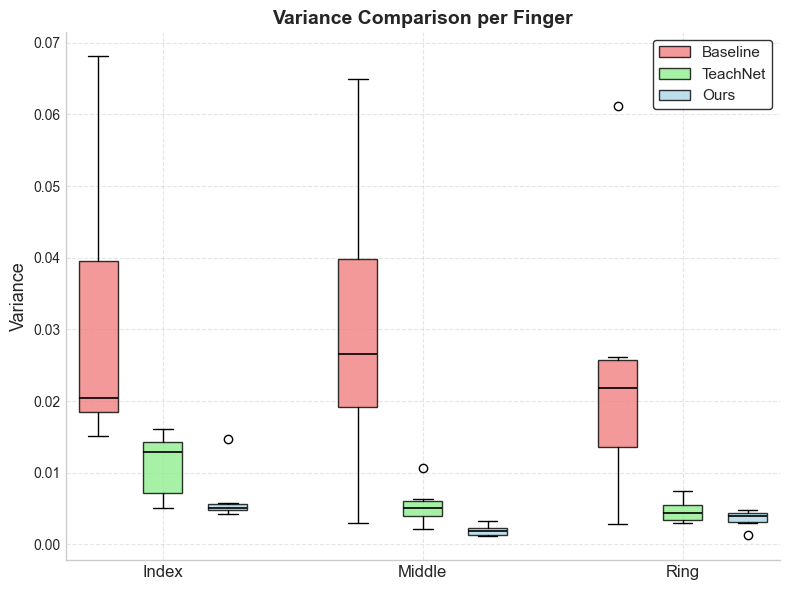

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 6))

mean_data = np.mean(data_array[:,:,:,:], axis=2)
baseline_data = mean_data[:,0,:]
teachnet_data = mean_data[:,1,:]
nn_data = mean_data[:,2,:]

# 파스텔톤 색상 (논문에서도 무난)
colors = ['lightcoral', 'lightgreen', 'lightblue']

# Boxplots (3 groups × 3 models)
b1 = ax.boxplot(baseline_data, positions=[1, 5, 9], widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor=colors[0], alpha=0.8, edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.2))
b2 = ax.boxplot(teachnet_data, positions=[2, 6, 10], widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor=colors[1], alpha=0.8, edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.2))
b3 = ax.boxplot(nn_data, positions=[3, 7, 11], widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor=colors[2], alpha=0.8, edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.2))

# 축 설정
ax.set_xticks([2, 6, 10])
ax.set_xticklabels(['Index', 'Middle', 'Ring'], fontsize=12)
ax.set_ylabel('Var', fontsize=13)
ax.set_title('Variance Comparison per Finger', fontsize=14, fontweight='bold')

# 범례
ax.legend([b1["boxes"][0], b2["boxes"][0], b3["boxes"][0]],
          ['Baseline', 'TeachNet', 'Ours'],
          loc='upper right', fontsize=11, frameon=True, edgecolor='black')

# 격자 및 외곽선 정리
ax.grid(True, linestyle='--', alpha=0.5)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


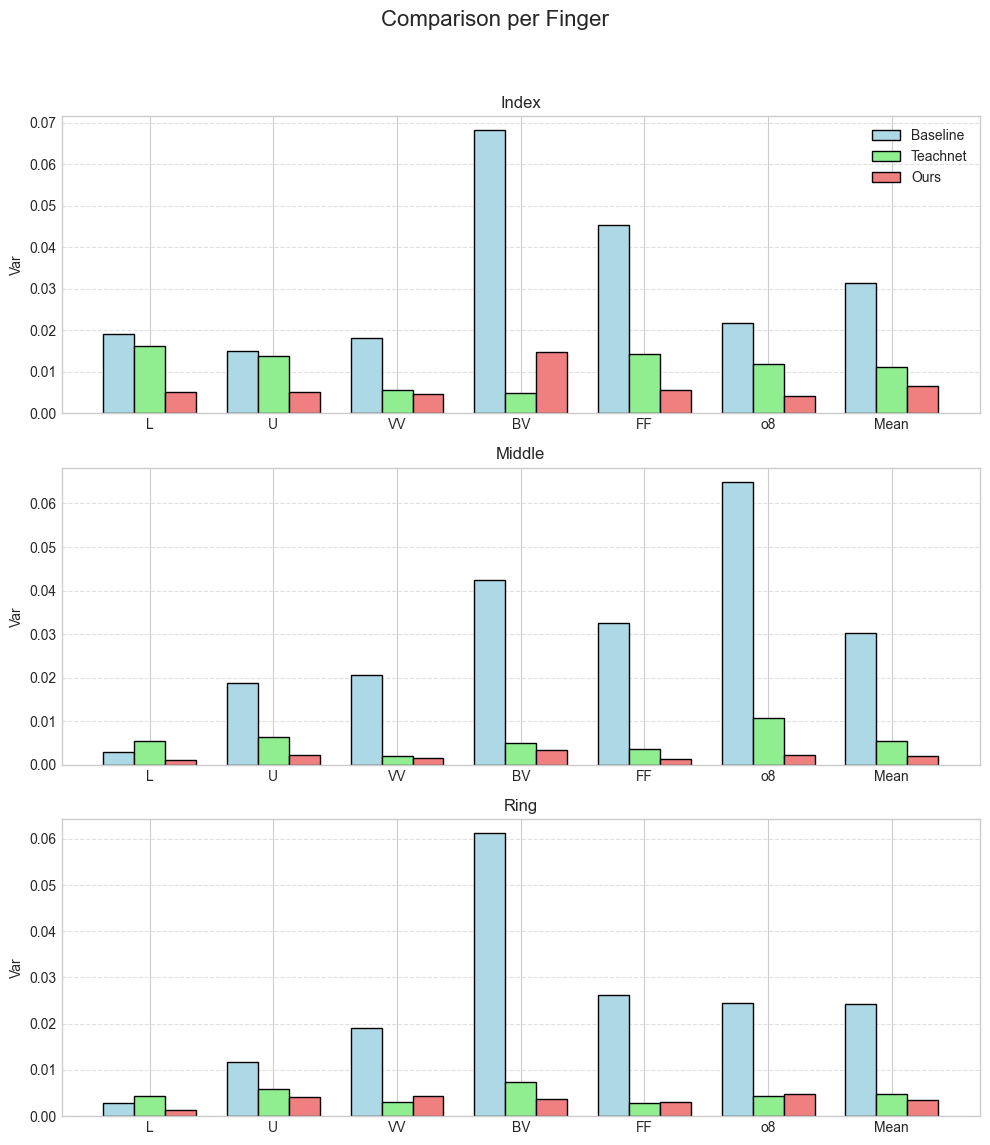

In [370]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 (예시 구조)
baseline_data = np.transpose(mean_data[:,0,:])  # shape (3, 6)
teachnet_data = np.transpose(mean_data[:,1,:])
nn_data = np.transpose(mean_data[:,2,:])

# 각 손가락별 평균을 마지막 column으로 추가
baseline_mean = baseline_data.mean(axis=1, keepdims=True)
teachnet_mean = teachnet_data.mean(axis=1, keepdims=True)
nn_mean = nn_data.mean(axis=1, keepdims=True)

baseline_data = np.hstack((baseline_data, baseline_mean))
teachnet_data = np.hstack((teachnet_data, teachnet_mean))
nn_data = np.hstack((nn_data, nn_mean))

# x축 위치 설정 (6 + 1)
x = np.arange(7)
width = 0.25
labels = pose_list + ['Mean']  # 기존 pose 이름 + 평균
labels[1] = "U"  # 기존 수정 유지
titles = ['Index', 'Middle', 'Ring']

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i in range(3):
    ax = axes[i]
    
    # 세 모델 각각의 막대
    ax.bar(x - width, baseline_data[i], width, label='Baseline', color='lightblue', edgecolor='black')
    ax.bar(x,         teachnet_data[i], width, label='Teachnet', color='lightgreen', edgecolor='black')
    ax.bar(x + width, nn_data[i], width, label='Ours', color='lightcoral', edgecolor='black')
    
    # x축, 제목 설정
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Var')
    ax.set_title(titles[i])
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    # 범례
    if i == 0:
        ax.legend(loc='upper right')

# 전체 제목
fig.suptitle('Comparison per Finger', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [323]:
baseline_data = mean_data[:,0,:]
baseline_data.shape

(6, 3)

In [15]:
joint['%time'] = pd.to_numeric(joint['%time'])
NN['%time'] = pd.to_numeric(NN['%time'])
cols_to_add = ['field.data8', 'field.data9', 'field.data10']  
merged = pd.merge_asof(
    joint.sort_values('%time'), 
    NN[['%time'] + cols_to_add].sort_values('%time'), 
    on='%time',
    direction='nearest'   
)


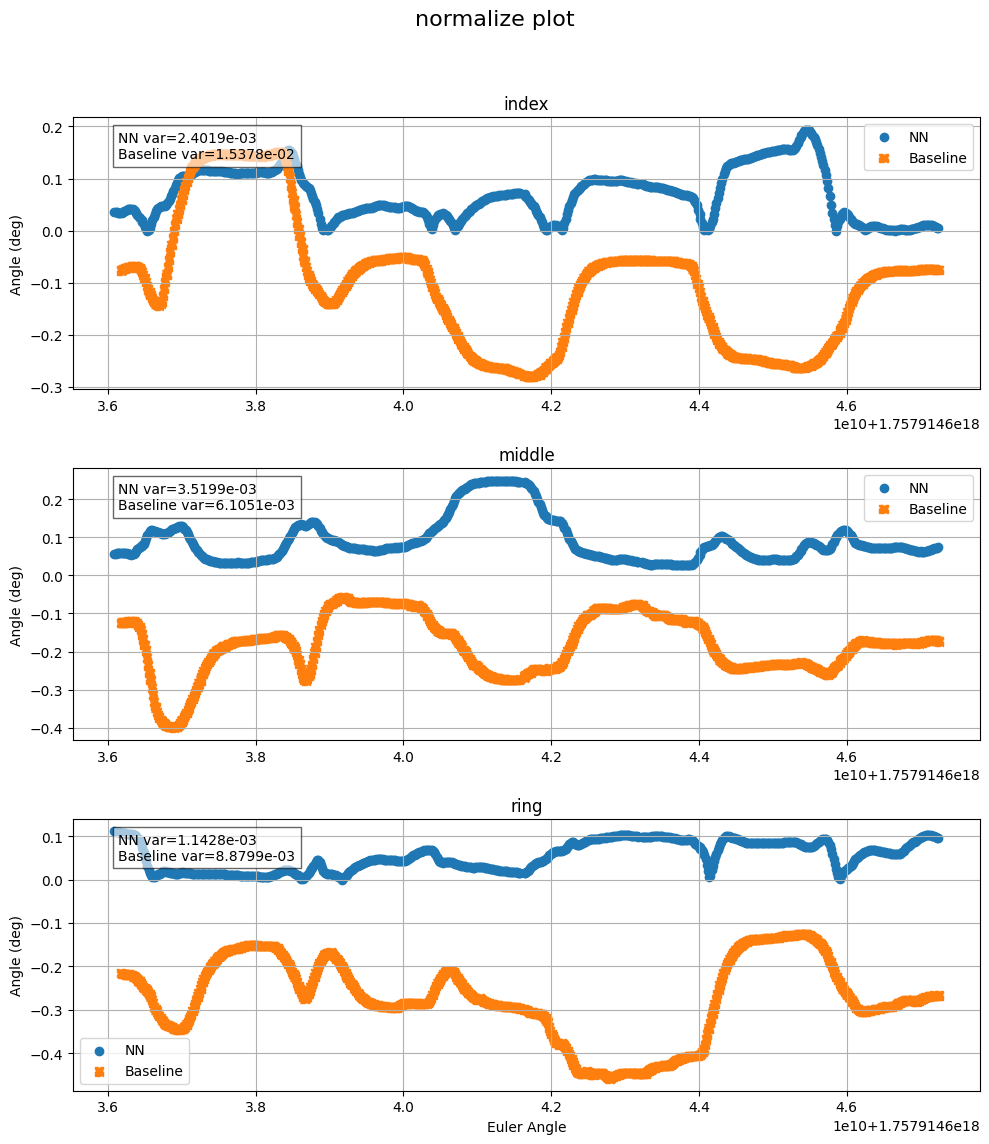

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# radTodeg = 180 / 3.14159265358979323846
radTodeg = 1

# Create subplots: 3 rows, 1 column
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
name = ["index", "middle", "ring"]

# Euler angle and finger columns for NN
euler_angle_NN = merged.columns[0]
finger_NN = merged.columns[5:8]

# Euler angle and finger columns for baseline
euler_angle_baseline = baseline.columns[0]
finger_baseline = baseline.columns[3:6]

# Plot loop
for i, (row_NN, row_baseline) in enumerate(zip(finger_NN, finger_baseline)):
    nn_norm =merged[row_NN] 
    baseline_norm = baseline[row_baseline] * radTodeg

    # variance 계산
    var_nn = nn_norm.var()
    var_baseline = baseline_norm.var()

    axes[i].scatter(merged[euler_angle_NN], nn_norm,
                    marker='o', linestyle='-', label="NN")
    axes[i].scatter(baseline[euler_angle_baseline], baseline_norm,
                    marker='s', linestyle='--', label="Baseline")

    # variance annotation
    axes[i].text(0.05, 0.95, 
                 f"NN var={var_nn:.4e}\nBaseline var={var_baseline:.4e}", 
                 transform=axes[i].transAxes,
                 verticalalignment='top',
                 fontsize=10,
                 bbox=dict(facecolor='white', alpha=0.6))

    axes[i].set_title(name[i])
    axes[i].set_ylabel("Angle (deg)")
    axes[i].grid(True)
    axes[i].legend()


# Add global title
fig.suptitle("normalize plot", fontsize=16)

plt.xlabel("Euler Angle")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leave space for suptitle
plt.show()


In [ ]:
init=[-0.1278197169303894, 1.9431181728839875, 12.401289129257203]
extend=[13.355320978164674, 10.181143426895142, -1.7475533306598663]

init = np.array([-0.1278197169303894, 1.9431181728839875, 12.401289129257203])
extend = np.array([13.355320978164674, 10.181143426895142, -1.7475533306598663])

diff = extend - init  # shape (3,)
diff = 15 * np.ones(3)

# make sure NN[finger_NN] is numpy array with shape (N,3)
modify = 0.35 * (NN[finger_NN] - init[None, :]) / diff[None, :]


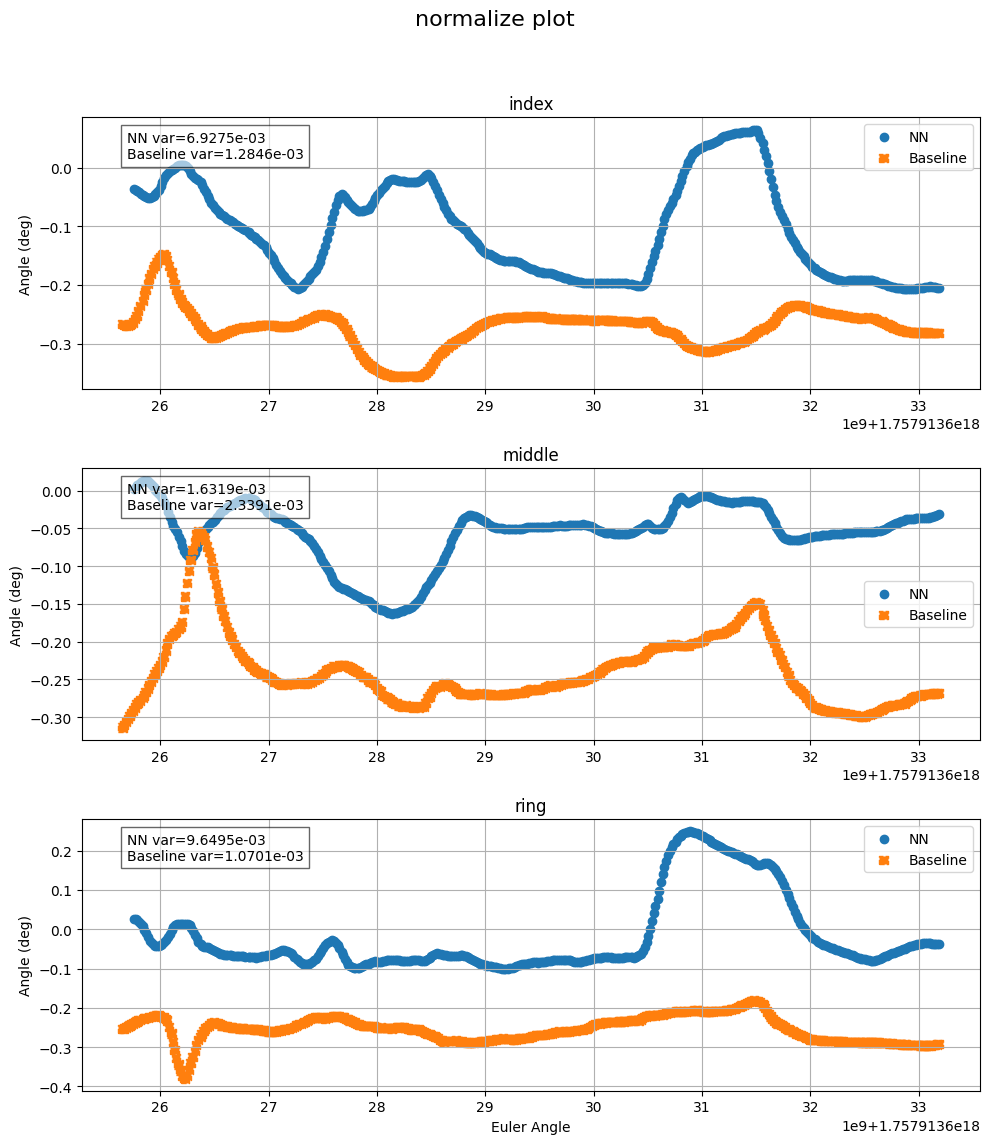

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# radTodeg = 180 / 3.14159265358979323846
radTodeg = 1

# Create subplots: 3 rows, 1 column
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
name = ["index", "middle", "ring"]

# Euler angle and finger columns for NN
euler_angle_NN = NN.columns[0]
finger_NN = NN.columns[3:6]

# Euler angle and finger columns for baseline
euler_angle_baseline = baseline.columns[0]
finger_baseline = baseline.columns[3:6]

# Plot loop
for i, (row_NN, row_baseline) in enumerate(zip(finger_NN, finger_baseline)):
    nn_norm = NN[row_NN] 
    baseline_norm = baseline[row_baseline] * radTodeg

    # variance 계산
    var_nn = modify.iloc[:,i].var()
    var_baseline = baseline_norm.var()

    axes[i].scatter(NN[euler_angle_NN], modify.iloc[:,i],
                    marker='o', linestyle='-', label="NN")
    axes[i].scatter(baseline[euler_angle_baseline], baseline_norm,
                    marker='s', linestyle='--', label="Baseline")

    # variance annotation
    axes[i].text(0.05, 0.95, 
                 f"NN var={var_nn:.4e}\nBaseline var={var_baseline:.4e}", 
                 transform=axes[i].transAxes,
                 verticalalignment='top',
                 fontsize=10,
                 bbox=dict(facecolor='white', alpha=0.6))

    axes[i].set_title(name[i])
    axes[i].set_ylabel("Angle (deg)")
    axes[i].grid(True)
    axes[i].legend()


# Add global title
fig.suptitle("normalize plot", fontsize=16)

plt.xlabel("Euler Angle")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leave space for suptitle
plt.show()


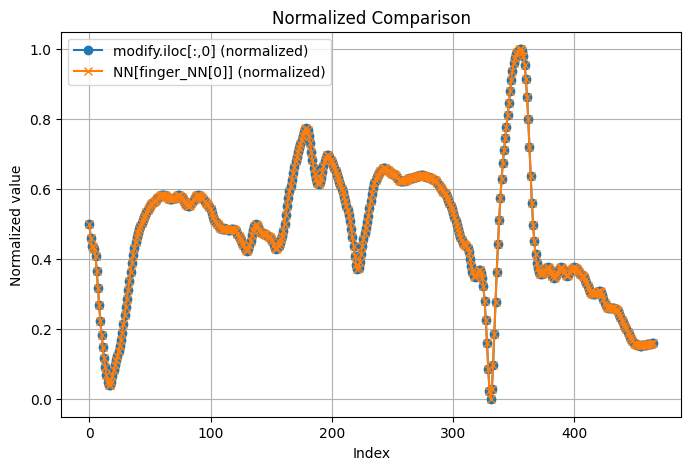

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# Extract data
vec1 = modify.iloc[:, 0].values          # shape (N,)
vec2 = NN[finger_NN[0]]                 # shape (3,)

# Normalize function (min-max normalization)
def normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))

# Normalize both vectors
vec1_norm = normalize(vec1)
vec2_norm = normalize(vec2)

# Plot
plt.figure(figsize=(8, 5))

# vec1 is 1D with length N, plot against its index
plt.plot(vec1_norm, label="modify.iloc[:,0] (normalized)", marker='o')

# vec2 is length 3, plot against index 0,1,2
plt.plot(range(len(vec2_norm)), vec2_norm, label="NN[finger_NN[0]] (normalized)", marker='x')

plt.xlabel("Index")
plt.ylabel("Normalized value")
plt.title("Normalized Comparison")
plt.legend()
plt.grid(True)
plt.show()
